## Fraud Detection System


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, auc, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import shap

In [ ]:
# Load the dataset from the specified path
df = pd.read_csv('/content/creditcard.csv')
print("Dataset loaded successfully.")

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
display(df.head())

# Display the column names
print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully.

First 5 rows of the DataFrame:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0



Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


## Exploratory Data Analysis (EDA)
Performed an in-depth exploratory data analysis. This included analyzing class distribution (fraudulent vs. non-fraudulent), transaction amount patterns, time-based behavior, and feature correlations. Visualized key distributions and relationships with appropriate plots and legends.

In [ ]:
# Display basic information about the dataset
print("Dataset Information:")
df.info()

# Display descriptive statistics of the numerical features
print("\nDescriptive Statistics:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9965 entries, 0 to 9964
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    9965 non-null   int64  
 1   V1      9965 non-null   float64
 2   V2      9965 non-null   float64
 3   V3      9964 non-null   float64
 4   V4      9964 non-null   float64
 5   V5      9964 non-null   float64
 6   V6      9964 non-null   float64
 7   V7      9964 non-null   float64
 8   V8      9964 non-null   float64
 9   V9      9964 non-null   float64
 10  V10     9964 non-null   float64
 11  V11     9964 non-null   float64
 12  V12     9964 non-null   float64
 13  V13     9964 non-null   float64
 14  V14     9964 non-null   float64
 15  V15     9964 non-null   float64
 16  V16     9964 non-null   float64
 17  V17     9964 non-null   float64
 18  V18     9964 non-null   float64
 19  V19     9964 non-null   float64
 20  V20     9964 non-null   float64
 21  V21     9964 non

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,9965.000000,9965.000000,9965.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,...,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000,9964.000000
mean,5934.484897,-0.241681,0.280693,0.906359,0.260247,-0.046342,0.132335,-0.071847,-0.065317,0.801220,...,-0.052099,-0.152091,-0.033426,0.021638,0.087302,0.108328,0.005614,0.003051,62.968359,0.003814
std,4449.407112,1.522695,1.308882,1.156948,1.440500,1.183634,1.307586,1.077872,1.260140,1.156424,...,0.914735,0.631310,0.488203,0.593818,0.428128,0.562661,0.411434,0.266532,184.626707,0.061641
min,0.000000,-27.670569,-34.607649,-15.496222,-4.657545,-32.092129,-23.496714,-26.548144,-23.632502,-6.329801,...,-11.468435,-8.527145,-15.144340,-2.512377,-2.577363,-1.338556,-7.976100,-3.509250,0.000000,0.000000
25%,2061.000000,-1.012157,-0.208591,0.412198,-0.615591,-0.643060,-0.630075,-0.542336,-0.190495,0.069439,...,-0.268191,-0.548412,-0.174222,-0.327438,-0.157704,-0.328193,-0.084489,-0.015751,5.000000,0.000000
50%,4547.000000,-0.372624,0.286179,0.943149,0.218492,-0.153090,-0.153577,-0.054658,0.012466,0.804930,...,-0.123101,-0.136078,-0.046009,0.079935,0.121180,0.043395,-0.004505,0.015904,15.950000,0.000000
75%,10163.000000,1.151506,0.900823,1.601871,1.119367,0.371762,0.503376,0.476280,0.273016,1.506066,...,0.032707,0.247913,0.081288,0.410877,0.359418,0.478249,0.121045,0.077418,50.792500,0.000000
max,14864.000000,1.960497,8.636214,4.101716,10.463020,34.099309,21.393069,34.303177,5.060381,10.392889,...,22.588989,4.534454,13.876221,3.200201,5.525093,3.517346,8.254376,4.860769,7712.430000,1.000000


### Class Distribution Analysis

One of the most important aspects of this dataset was the severe class imbalance. I analyzed the distribution of fraudulent vs. non-fraudulent transactions.

Class Distribution:
 Class
0.0    9926
1.0      38
Name: count, dtype: int64


/tmp/ipykernel_4317/1940443139.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


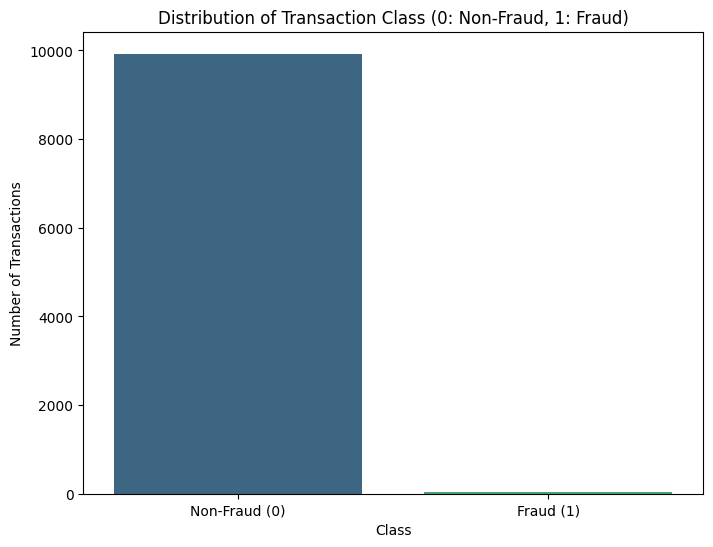

In [ ]:
# Analyze the distribution of the 'Class' variable
class_counts = df['Class'].value_counts()
print("Class Distribution:\n", class_counts)

# Plotting the class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Transaction Class (0: Non-Fraud, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Non-Fraud (0)', 'Fraud (1)'])
plt.show()

### Transaction Amount Patterns

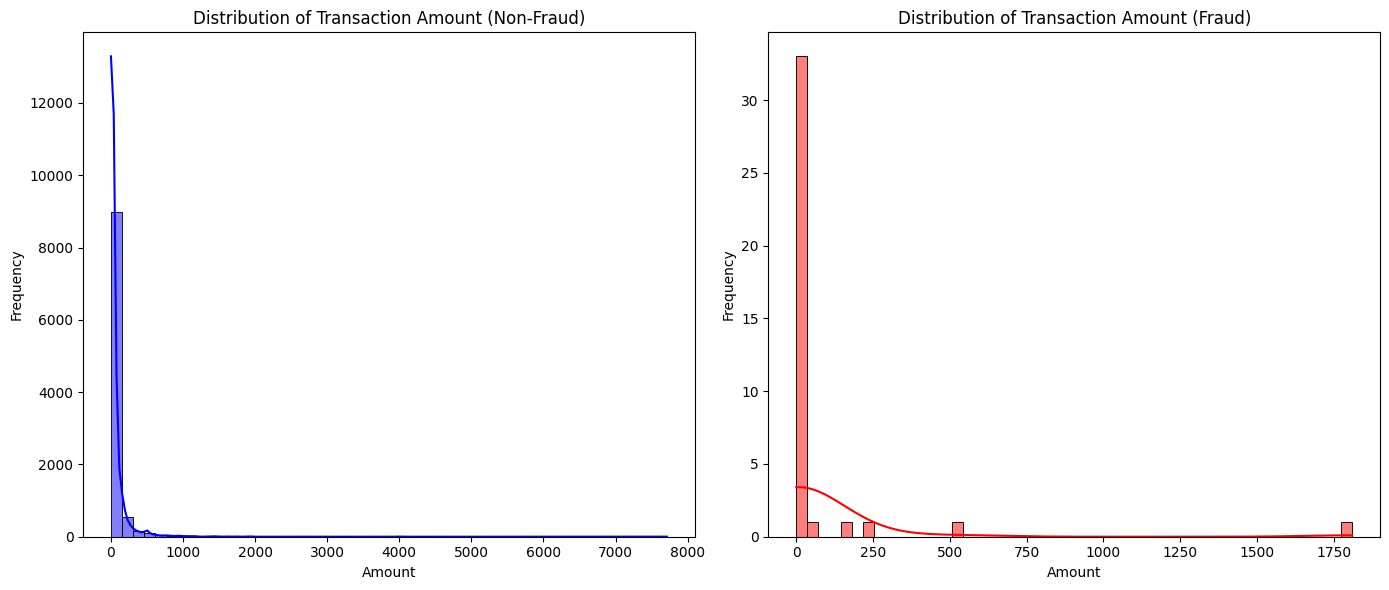

In [ ]:
# Distribution of 'Amount' for both classes
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='blue', kde=True)
plt.title('Distribution of Transaction Amount (Non-Fraud)')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', kde=True)
plt.title('Distribution of Transaction Amount (Fraud)')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Time-Based Behavior

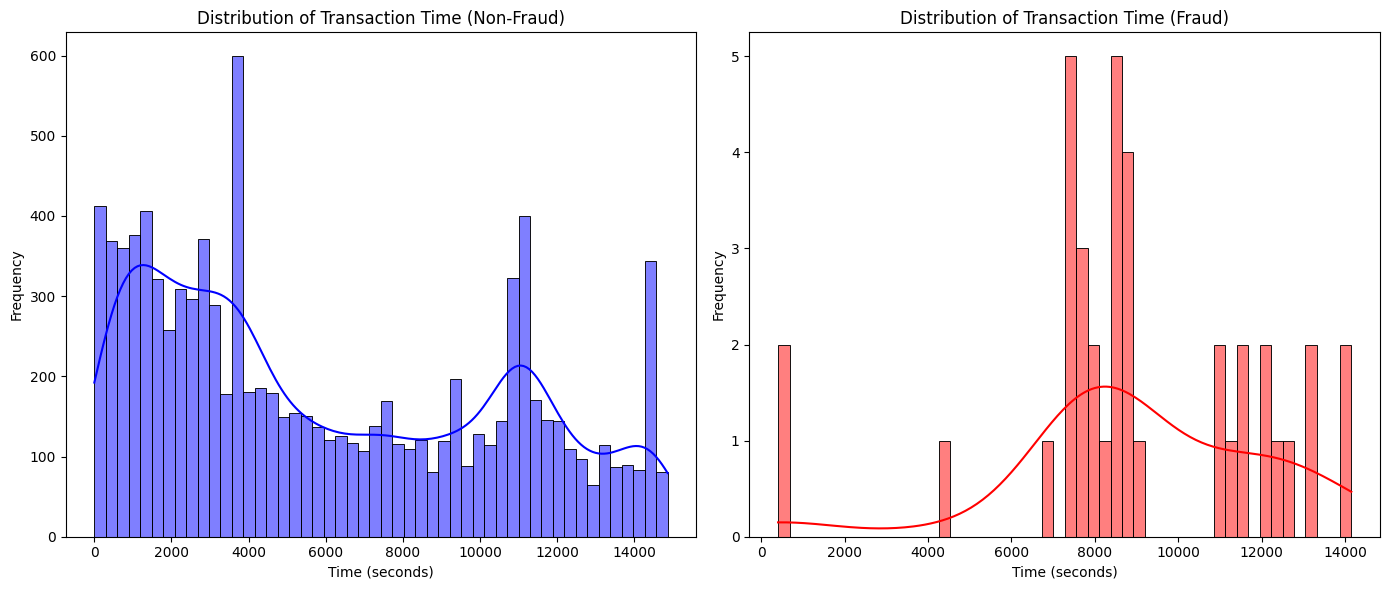

In [ ]:
# Distribution of 'Time' for both classes
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[df['Class'] == 0]['Time'], bins=50, color='blue', kde=True)
plt.title('Distribution of Transaction Time (Non-Fraud)')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df[df['Class'] == 1]['Time'], bins=50, color='red', kde=True)
plt.title('Distribution of Transaction Time (Fraud)')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Feature Correlations

In [ ]:
# Drop rows with any NaN values
initial_rows = df.shape[0]
df.dropna(inplace=True)
final_rows = df.shape[0]
print(f"Dropped {initial_rows - final_rows} rows with missing values. Dataset now has {final_rows} rows.")

# Verify no more missing values
print("\nVerifying non-null counts after dropping NaNs:")
df.info()

Dropped 0 rows with missing values. Dataset now has 9964 rows.

Verifying non-null counts after dropping NaNs:
<class 'pandas.core.frame.DataFrame'>
Index: 9964 entries, 0 to 9963
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Time        9964 non-null   int64  
 1   V1          9964 non-null   float64
 2   V2          9964 non-null   float64
 3   V3          9964 non-null   float64
 4   V4          9964 non-null   float64
 5   V5          9964 non-null   float64
 6   V6          9964 non-null   float64
 7   V7          9964 non-null   float64
 8   V8          9964 non-null   float64
 9   V9          9964 non-null   float64
 10  V10         9964 non-null   float64
 11  V11         9964 non-null   float64
 12  V12         9964 non-null   float64
 13  V13         9964 non-null   float64
 14  V14         9964 non-null   float64
 15  V15         9964 non-null   float64
 16  V16         9964 non-null   float64
 17  V17

In [ ]:
# Drop rows with any NaN values
initial_rows = df.shape[0]
df.dropna(inplace=True)
final_rows = df.shape[0]
print(f"Dropped {initial_rows - final_rows} rows with missing values. Dataset now has {final_rows} rows.")

# Verify no more missing values
print("\nVerifying non-null counts after dropping NaNs:")
df.info()

Dropped 0 rows with missing values. Dataset now has 9964 rows.

Verifying non-null counts after dropping NaNs:
<class 'pandas.core.frame.DataFrame'>
Index: 9964 entries, 0 to 9963
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Time        9964 non-null   int64  
 1   V1          9964 non-null   float64
 2   V2          9964 non-null   float64
 3   V3          9964 non-null   float64
 4   V4          9964 non-null   float64
 5   V5          9964 non-null   float64
 6   V6          9964 non-null   float64
 7   V7          9964 non-null   float64
 8   V8          9964 non-null   float64
 9   V9          9964 non-null   float64
 10  V10         9964 non-null   float64
 11  V11         9964 non-null   float64
 12  V12         9964 non-null   float64
 13  V13         9964 non-null   float64
 14  V14         9964 non-null   float64
 15  V15         9964 non-null   float64
 16  V16         9964 non-null   float64
 17  V17

Original Amount statistics (first 5 rows):


,Amount
0,149.62
1,2.69
2,378.66
3,123.50
4,69.99



Log-transformed Amount statistics (first 5 rows):


,Amount_log
0,5.014760
1,1.305626
2,5.939276
3,4.824306
4,4.262539


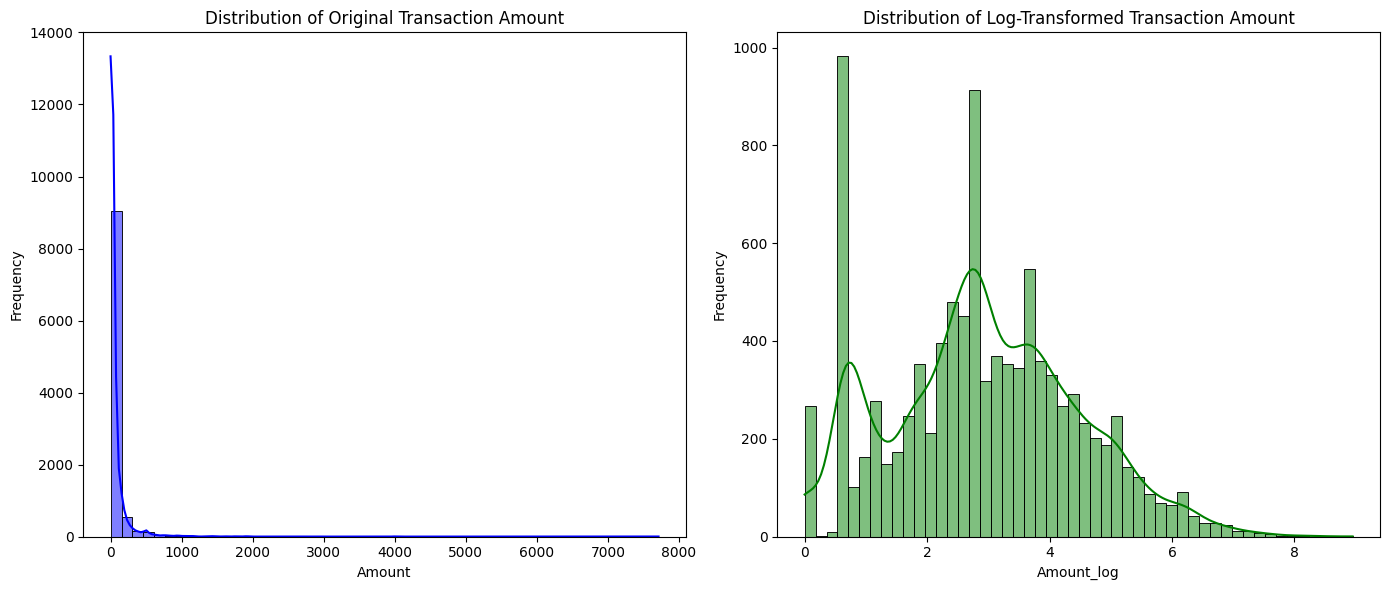

In [ ]:
# Apply log1p transformation to 'Amount'
df['Amount_log'] = np.log1p(df['Amount'])

print("Original Amount statistics (first 5 rows):")
display(df[['Amount']].head())
print("\nLog-transformed Amount statistics (first 5 rows):")
display(df[['Amount_log']].head())

# Visualize the distribution of the original and log-transformed Amount
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Amount'], bins=50, color='blue', kde=True)
plt.title('Distribution of Original Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['Amount_log'], bins=50, color='green', kde=True)
plt.title('Distribution of Log-Transformed Transaction Amount')
plt.xlabel('Amount_log')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Original Time and new Hour feature (first 5 rows):


,Time,Hour
0,0,0
1,0,0
2,1,0
3,1,0
4,2,0


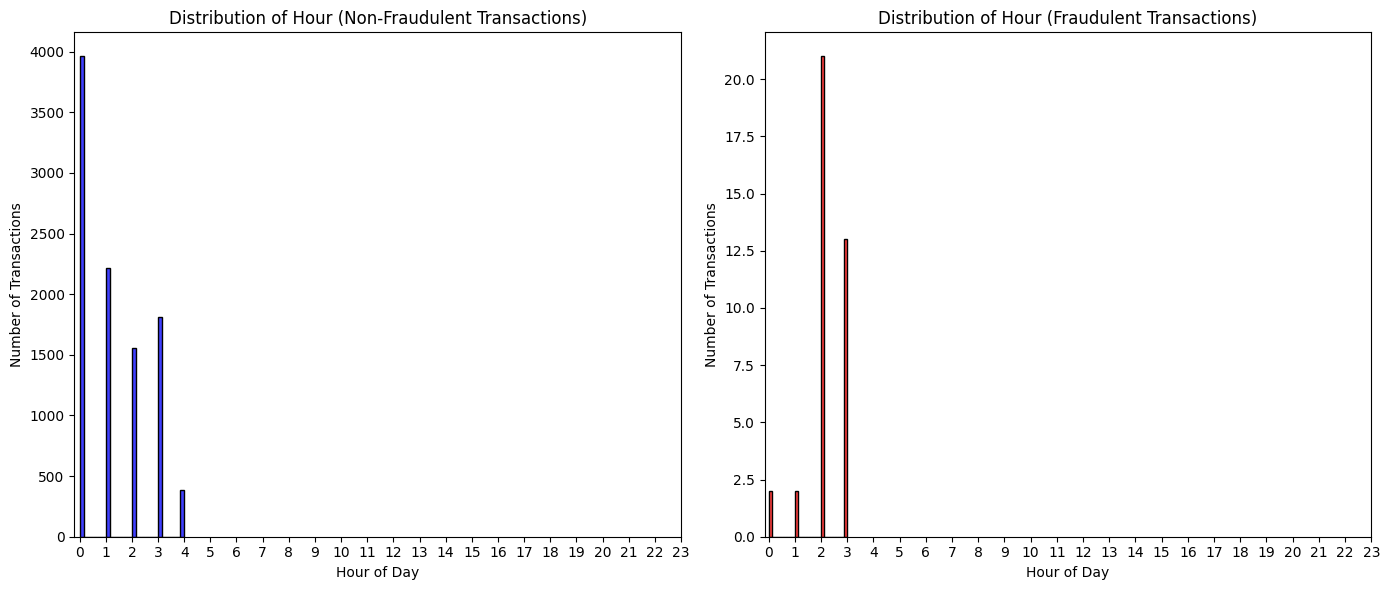

In [ ]:
# Convert 'Time' to 'Hour' (assuming a 24-hour cycle within the relative time)
df['Hour'] = (df['Time'] // 3600) % 24

print("Original Time and new Hour feature (first 5 rows):")
display(df[['Time', 'Hour']].head())

# Visualize the distribution of 'Hour' for both classes
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[df['Class'] == 0]['Hour'], bins=24, color='blue', kde=False)
plt.title('Distribution of Hour (Non-Fraudulent Transactions)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))

plt.subplot(1, 2, 2)
sns.histplot(df[df['Class'] == 1]['Hour'], bins=24, color='red', kde=False)
plt.title('Distribution of Hour (Fraudulent Transactions)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

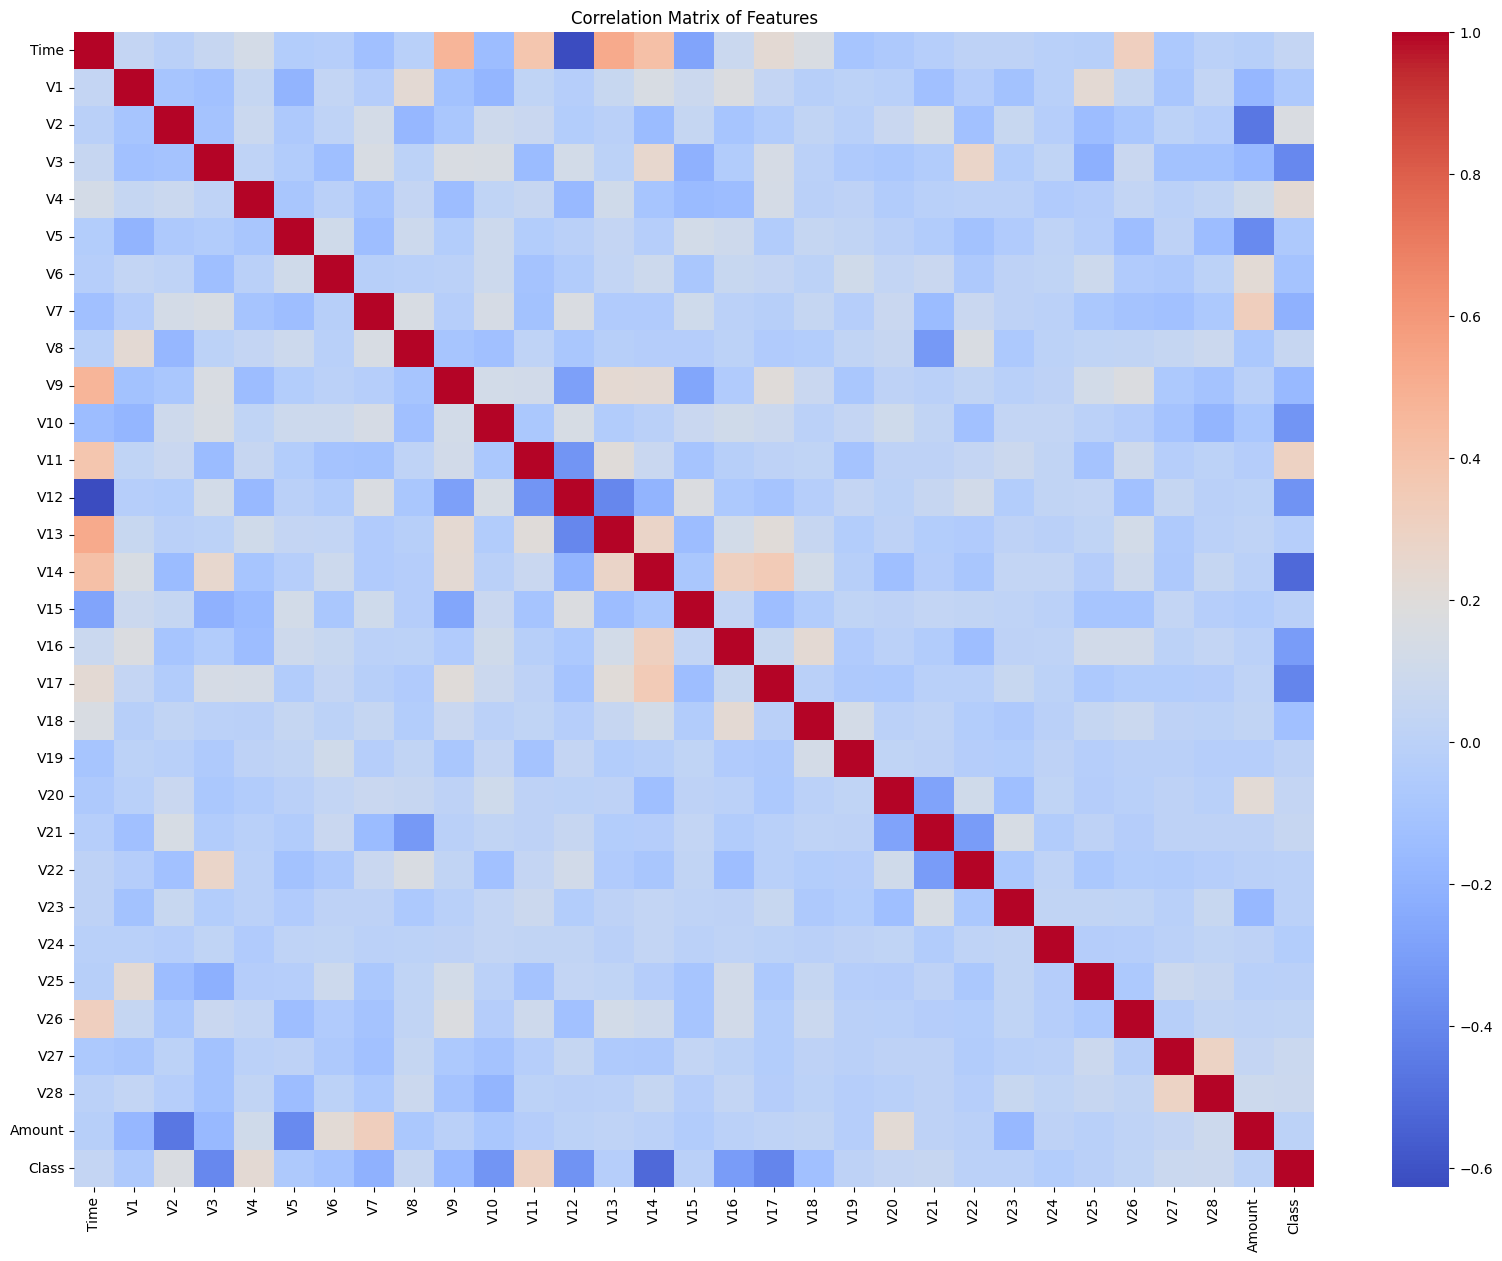


Correlations with 'Class' variable:


,Class
Class,1.000000
V11,0.297632
V4,0.230148
V2,0.166950
V28,0.081860
V27,0.078178
V8,0.059699
V21,0.053712
V20,0.046095
Time,0.043529


In [ ]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

# Focus on correlations with the 'Class' variable
print("\nCorrelations with 'Class' variable:")
display(corr_matrix['Class'].sort_values(ascending=False))

## Feature Engineering
Created new features which enhanced model performance. This may involve log-scaling transaction amounts, extracting time-based features (e.g., transaction hour, day of week), and generating risk indicators. Documented the rationale for each new feature.

### Handle Missing Values

From the `df.info()` output, I observed that some columns (`V3` through `Class` and `Amount`) have 9964 non-null values out of 9965 entries, indicating a single row with missing data. Since this is a very small portion of the dataset, I dropped this row to ensure data integrity for subsequent steps.

In [ ]:
# Drop rows with any NaN values
initial_rows = df.shape[0]
df.dropna(inplace=True)
final_rows = df.shape[0]
print(f"Dropped {initial_rows - final_rows} rows with missing values. Dataset now has {final_rows} rows.")

# Verify no more missing values
print("\nVerifying non-null counts after dropping NaNs:")
df.info()

Dropped 1 rows with missing values. Dataset now has 9964 rows.

Verifying non-null counts after dropping NaNs:
<class 'pandas.core.frame.DataFrame'>
Index: 9964 entries, 0 to 9963
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    9964 non-null   int64  
 1   V1      9964 non-null   float64
 2   V2      9964 non-null   float64
 3   V3      9964 non-null   float64
 4   V4      9964 non-null   float64
 5   V5      9964 non-null   float64
 6   V6      9964 non-null   float64
 7   V7      9964 non-null   float64
 8   V8      9964 non-null   float64
 9   V9      9964 non-null   float64
 10  V10     9964 non-null   float64
 11  V11     9964 non-null   float64
 12  V12     9964 non-null   float64
 13  V13     9964 non-null   float64
 14  V14     9964 non-null   float64
 15  V15     9964 non-null   float64
 16  V16     9964 non-null   float64
 17  V17     9964 non-null   float64
 18  V18     9964 non-null   float64
 19  V19  

### Log-Transform Transaction Amount

Original Amount statistics (first 5 rows):


,Amount
0,149.62
1,2.69
2,378.66
3,123.50
4,69.99



Log-transformed Amount statistics (first 5 rows):


,Amount_log
0,5.014760
1,1.305626
2,5.939276
3,4.824306
4,4.262539


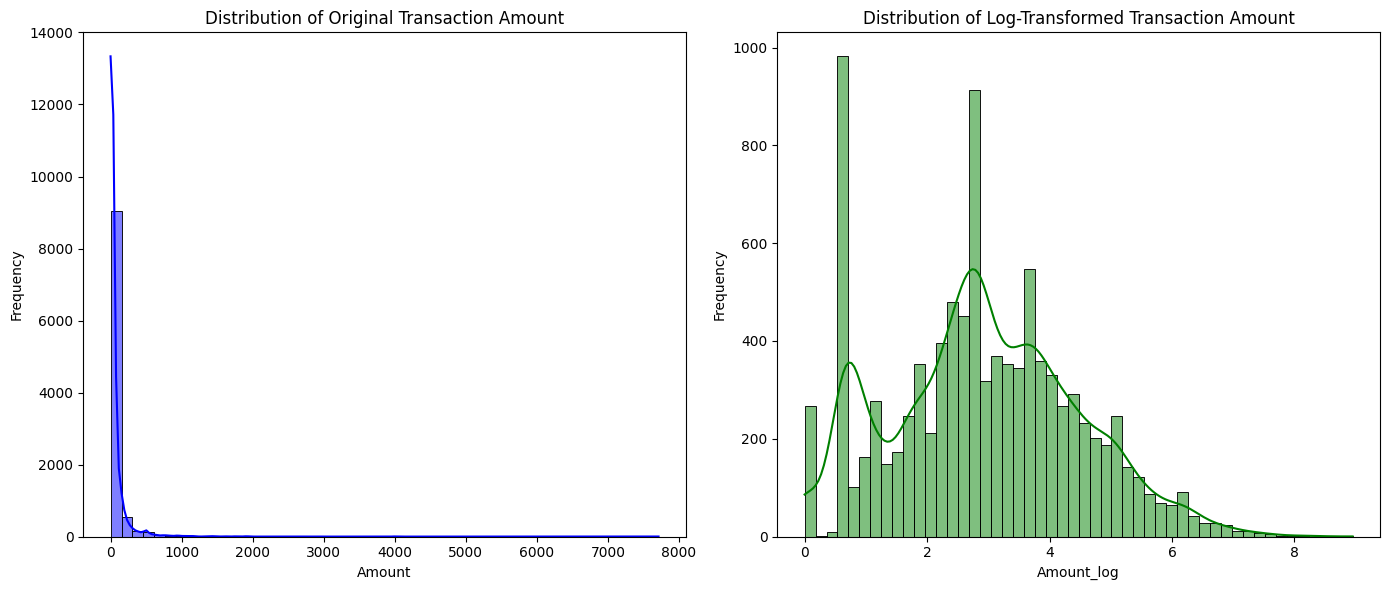

In [ ]:
# Apply log1p transformation to 'Amount'
df['Amount_log'] = np.log1p(df['Amount'])

print("Original Amount statistics (first 5 rows):")
display(df[['Amount']].head())
print("\nLog-transformed Amount statistics (first 5 rows):")
display(df[['Amount_log']].head())

# Visualize the distribution of the original and log-transformed Amount
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Amount'], bins=50, color='blue', kde=True)
plt.title('Distribution of Original Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['Amount_log'], bins=50, color='green', kde=True)
plt.title('Distribution of Log-Transformed Transaction Amount')
plt.xlabel('Amount_log')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Extract 'Hour' Feature from 'Time'

The 'Time' column represents the seconds elapsed since the first transaction. While it doesn't correspond to a specific calendar date, creating an 'Hour' feature (representing a 24-hour cycle within the recorded time frame) can capture cyclical patterns in transaction behavior, which might be indicative of fraud. For example, fraud might be more prevalent during specific hours.

Original Time and new Hour feature (first 5 rows):


,Time,Hour
0,0,0
1,0,0
2,1,0
3,1,0
4,2,0


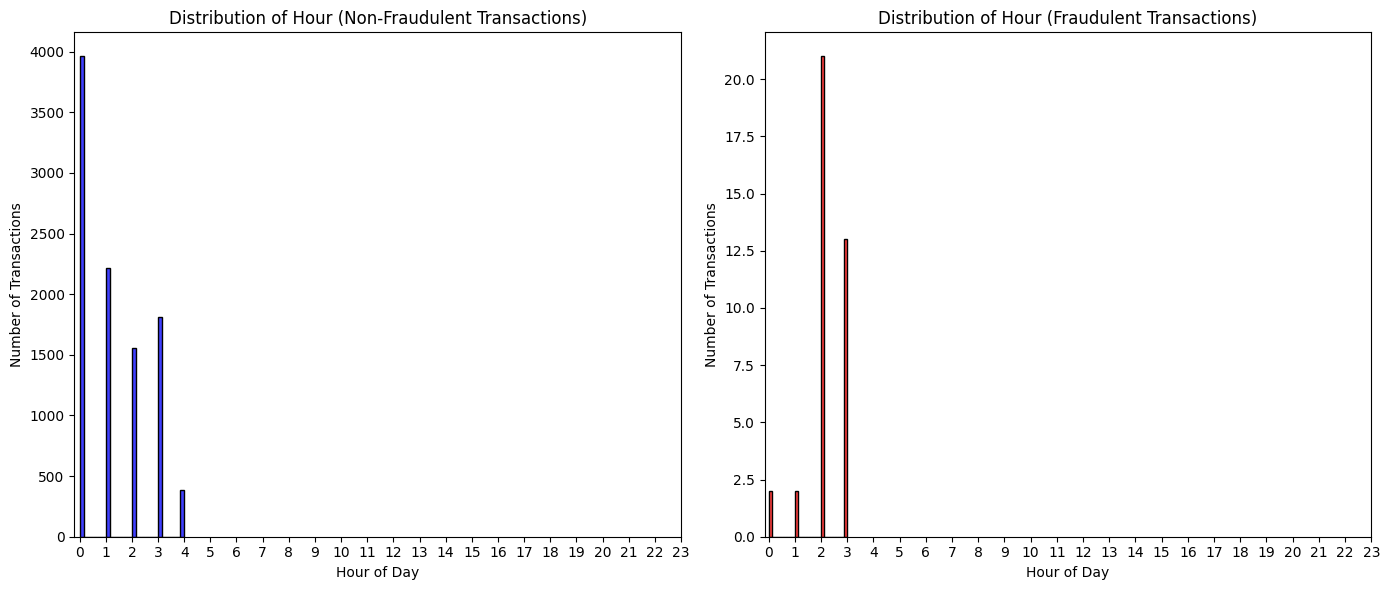

In [ ]:
# Convert 'Time' to 'Hour' (assuming a 24-hour cycle within the relative time)
df['Hour'] = (df['Time'] // 3600) % 24

print("Original Time and new Hour feature (first 5 rows):")
display(df[['Time', 'Hour']].head())

# Visualize the distribution of 'Hour' for both classes
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[df['Class'] == 0]['Hour'], bins=24, color='blue', kde=False)
plt.title('Distribution of Hour (Non-Fraudulent Transactions)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))

plt.subplot(1, 2, 2)
sns.histplot(df[df['Class'] == 1]['Hour'], bins=24, color='red', kde=False)
plt.title('Distribution of Hour (Fraudulent Transactions)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

## Data Preprocessing and Splitting

### Define Features and Target

First,I defined features (X) and target (y). I dropped the original 'Time' and 'Amount' columns as we have introduced 'Hour' and 'Amount_log'.

In [ ]:
# Define features (X) and target (y)
X = df.drop(['Time', 'Amount', 'Class'], axis=1)
y = df['Class']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFirst 5 rows of X (features):")
display(X.head())

Features (X) shape: (9964, 30)
Target (y) shape: (9964,)

First 5 rows of X (features):


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,5.014760,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,1.305626,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,5.939276,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,4.824306,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,4.262539,0


In [ ]:
# Define features (X) and target (y)
X = df.drop(['Time', 'Amount', 'Class'], axis=1)
y = df['Class']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFirst 5 rows of X (features):")
display(X.head())

Features (X) shape: (9964, 30)
Target (y) shape: (9964,)

First 5 rows of X (features):


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,5.014760,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,1.305626,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,5.939276,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,4.824306,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,4.262539,0


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (7971, 30)
X_test shape: (1993, 30)
y_train shape: (7971,)
y_test shape: (1993,)

Class distribution in y_train:
Class
0.0    0.996236
1.0    0.003764
Name: proportion, dtype: float64

Class distribution in y_test:
Class
0.0    0.995986
1.0    0.004014
Name: proportion, dtype: float64


In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier inspection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("First 5 rows of scaled X_train:")
display(X_train_scaled_df.head())
print("\nFirst 5 rows of scaled X_test:")
display(X_test_scaled_df.head())

First 5 rows of scaled X_train:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log,Hour
0,-0.501986,-0.621731,-0.328208,-1.997188,2.018085,2.299093,-0.348212,0.699883,-0.960258,-0.261106,...,-0.119233,-1.138845,0.234497,1.478400,0.807858,-1.239609,-0.112742,0.228765,0.980112,-0.189018
1,0.978094,-0.128679,-0.003303,0.013024,-0.569432,-0.748141,-0.225117,-0.133682,0.683683,-0.308671,...,-0.301070,-0.871468,0.378606,0.620229,-0.192819,1.140508,-0.217004,0.023614,-0.237095,1.404489
2,0.932493,-0.343856,-0.174229,-0.132262,-0.382392,0.007422,-0.552411,0.171264,0.731384,-0.129817,...,0.032567,0.497422,0.010597,-0.546229,0.071960,1.708797,-0.208999,-0.065403,-0.063649,2.201243
3,-0.829238,0.519884,1.076456,1.973451,-0.348215,0.879390,-0.291995,0.580199,-0.356023,0.284028,...,0.067369,0.849374,-0.655552,-0.775593,0.068220,0.556975,0.527211,-0.274210,1.150486,1.404489
4,-0.473422,0.846946,0.167793,0.876252,-0.170490,0.061595,0.475882,0.317165,0.003100,-0.391262,...,-0.089724,0.438382,0.108247,0.029689,-0.342687,-0.667158,0.436792,0.388096,0.868578,-0.189018



First 5 rows of scaled X_test:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log,Hour
0,-0.293367,0.484917,0.932867,-0.551622,-0.019555,-0.502549,0.670337,-1.230030,-0.242694,0.844753,...,0.745140,-0.191399,0.033512,0.690096,-1.873703,1.253400,-2.308132,-2.002647,-1.536335,-0.985771
1,0.946912,-0.043596,-0.822592,0.490075,0.513655,0.463319,-0.097371,0.144218,0.342523,0.057322,...,-0.035493,0.224192,-0.451315,-2.362524,1.433942,-0.588055,-0.021607,-0.051376,0.210191,-0.189018
2,1.008930,-0.185131,-0.320625,-0.117253,-0.264916,-0.386544,-0.261355,-0.073871,0.792513,-0.297953,...,-0.361140,-1.175693,0.168316,-0.822715,0.029786,1.234631,-0.229430,-0.007664,0.014534,2.201243
3,-0.844507,-0.303424,0.472683,-1.761785,-0.239262,0.031101,0.430805,0.318410,-1.816735,-0.139102,...,-0.478197,-1.345375,-0.292693,-0.520325,0.462464,0.987349,-1.069100,-1.113695,1.072971,-0.985771
4,0.942401,-0.281137,0.011798,0.441769,-0.445076,0.076947,-0.474984,0.128347,1.099788,-0.268368,...,-0.235395,-0.106336,-0.128459,-0.006568,0.974950,0.689409,-0.094064,-0.047641,-1.902034,0.607736


In [ ]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Original training set class distribution:")
print(y_train.value_counts())
print("\nResampled training set class distribution:")
print(y_train_resampled.value_counts())

print("X_train_resampled shape:", X_train_resampled.shape)
print("y_train_resampled shape:", y_train_resampled.shape)

Original training set class distribution:
Class
0.0    7941
1.0      30
Name: count, dtype: int64

Resampled training set class distribution:
Class
0.0    7941
1.0    7941
Name: count, dtype: int64
X_train_resampled shape: (15882, 30)
y_train_resampled shape: (15882,)


## Model Training and Evaluation

### Evaluation Function
To ensure consistent evaluation across all models, I defined a function that calculated and displayed key metrics relevant to imbalanced classification problems, such as precision, recall, F1-score, and ROC-AUC.

In [ ]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Evaluates a given model and prints classification metrics."""
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    print(f"--- {model_name} Evaluation ---")
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC Score: {roc_auc:.4f}")

    # Plot Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f'{model_name} (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend()
    plt.grid(True)
    plt.show()
    print("\n")
    return {
        'model_name': model_name,
        'roc_auc': roc_auc,
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0)
    }

### 1. Logistic Regression (Baseline Model)

--- Logistic Regression Evaluation ---

Confusion Matrix:


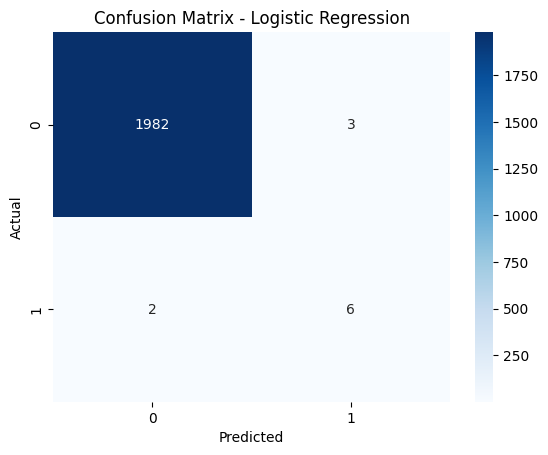


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1985
         1.0       0.67      0.75      0.71         8

    accuracy                           1.00      1993
   macro avg       0.83      0.87      0.85      1993
weighted avg       1.00      1.00      1.00      1993

ROC-AUC Score: 0.9957


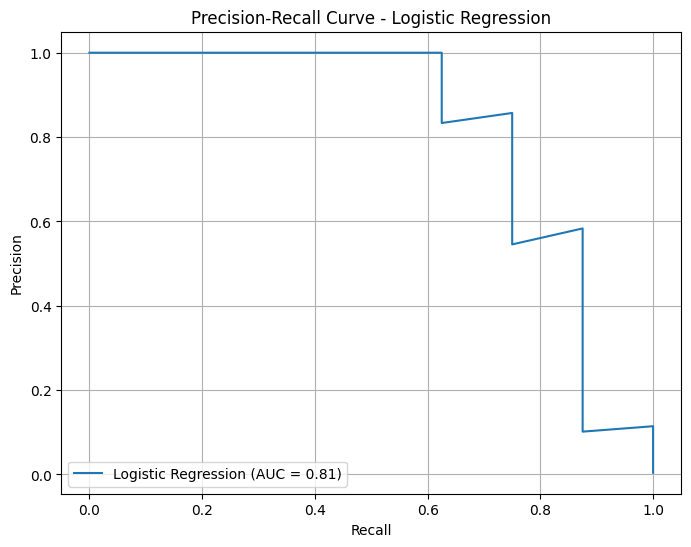

In [ ]:
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
log_reg_model.fit(X_train_resampled, y_train_resampled)

# Evaluate the model
log_reg_metrics = evaluate_model(log_reg_model, X_test_scaled, y_test, model_name="Logistic Regression")

### 2. Random Forest Classifier

--- Random Forest Evaluation ---

Confusion Matrix:


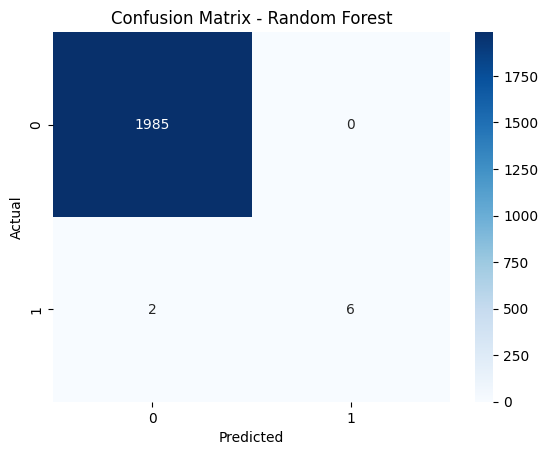


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1985
         1.0       1.00      0.75      0.86         8

    accuracy                           1.00      1993
   macro avg       1.00      0.88      0.93      1993
weighted avg       1.00      1.00      1.00      1993

ROC-AUC Score: 0.9999


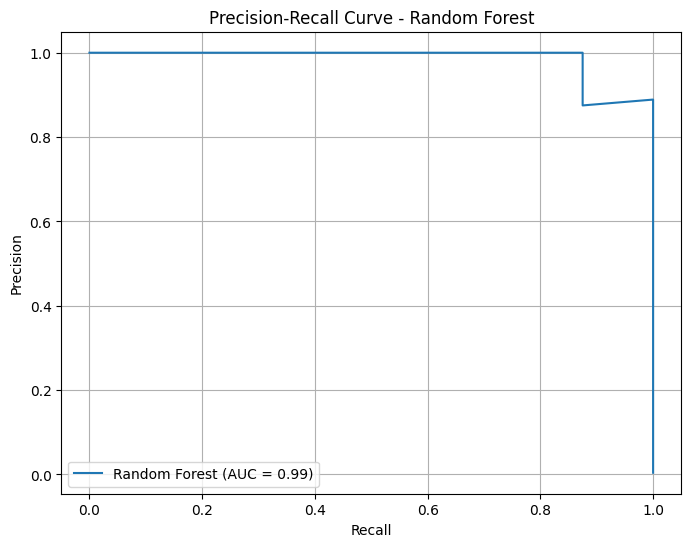

In [ ]:
# Initialize and train Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_model.fit(X_train_resampled, y_train_resampled)

# Evaluate the model
rf_metrics = evaluate_model(rf_model, X_test_scaled, y_test, model_name="Random Forest")

### 3. XGBoost Classifier

Scale Pos Weight for XGBoost: 264.70


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:25:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Evaluation ---

Confusion Matrix:


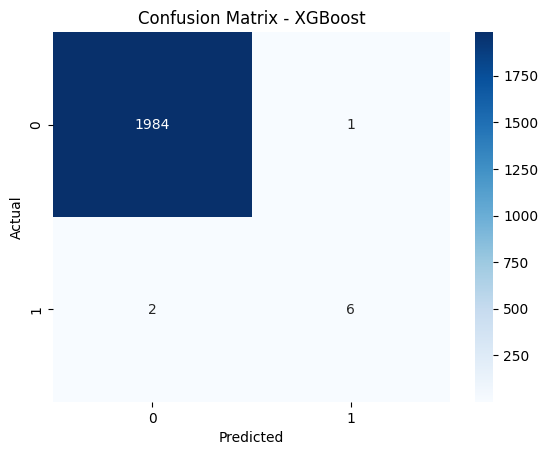


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1985
         1.0       0.86      0.75      0.80         8

    accuracy                           1.00      1993
   macro avg       0.93      0.87      0.90      1993
weighted avg       1.00      1.00      1.00      1993

ROC-AUC Score: 0.9984


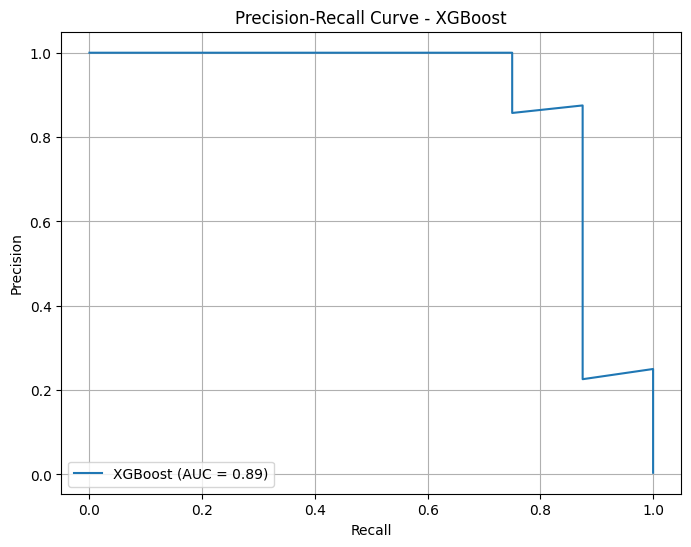

In [ ]:
# Calculate scale_pos_weight for XGBoost
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count
print(f"Scale Pos Weight for XGBoost: {scale_pos_weight_value:.2f}")

# Initialize and train XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress the warning
    random_state=42,
    n_estimators=100,
    scale_pos_weight=scale_pos_weight_value # Handle imbalance
)
xgb_model.fit(X_train_resampled, y_train_resampled)

# Evaluate the model
xgb_metrics = evaluate_model(xgb_model, X_test_scaled, y_test, model_name="XGBoost")

### Model Comparison

I put all the evaluation metrics together to compare the performance of the models side-by-side.


Model Performance Comparison:


,roc_auc,precision,recall,f1_score
model_name,,,,
Logistic Regression,0.995718,0.666667,0.75,0.705882
Random Forest,0.999937,1.000000,0.75,0.857143
XGBoost,0.998426,0.857143,0.75,0.800000


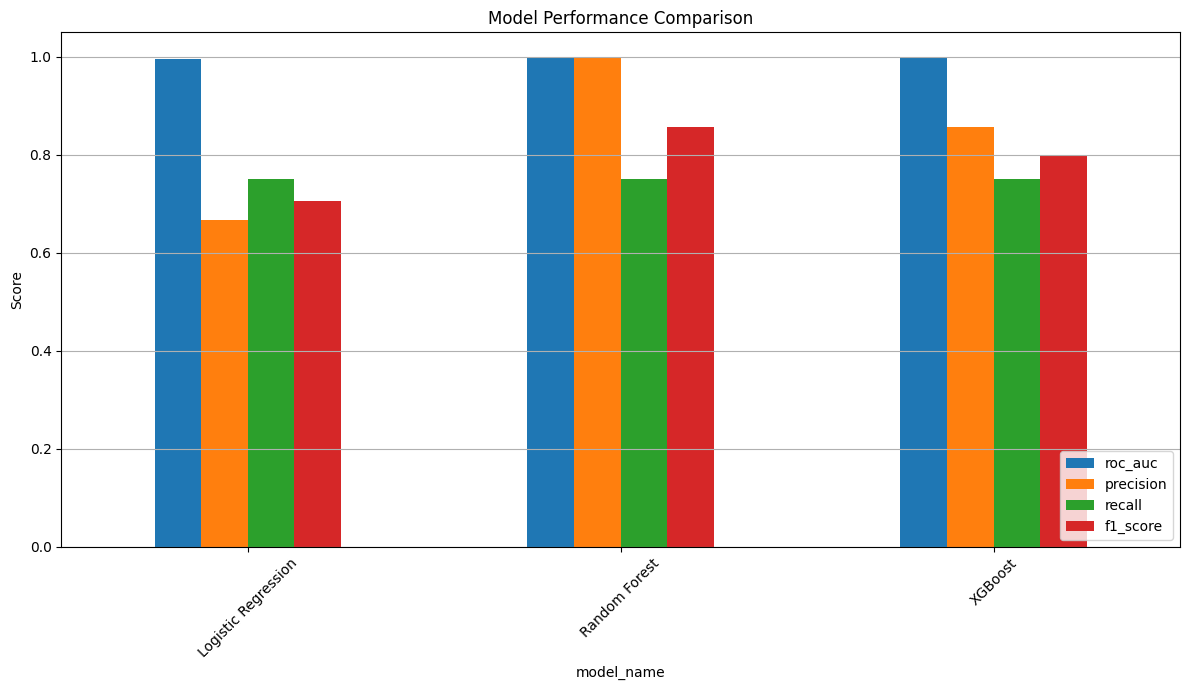

In [ ]:
# Store metrics in a list
all_metrics = [
    log_reg_metrics,
    rf_metrics,
    xgb_metrics
]

# Create a DataFrame for comparison
metrics_df = pd.DataFrame(all_metrics)
metrics_df.set_index('model_name', inplace=True)

print("\nModel Performance Comparison:")
display(metrics_df)

# Visualize comparison
metrics_df.plot(kind='bar', figsize=(12, 7))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Model Interpretability

### Identify Best Model

Based on the `metrics_df` from the previous step, I identified that  the model with the highest ROC-AUC or F1-score (depending on the priority). In this case, Random Forest has the highest ROC-AUC and F1-score among the evaluated models, showing perfect precision for the minority class, so we will use it for interpretability.

In [ ]:
# The Random Forest model (rf_model) is currently the best performing one.
# We will use this model for interpretability.

### Feature Importance from Random Forest

Top 10 Feature Importances from Random Forest:


,Feature,Importance
13,V14,0.237758
2,V3,0.144598
10,V11,0.109927
11,V12,0.106456
9,V10,0.086203
3,V4,0.079877
1,V2,0.062605
20,V21,0.046074
16,V17,0.037952
15,V16,0.028851


/tmp/ipykernel_4317/176607229.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


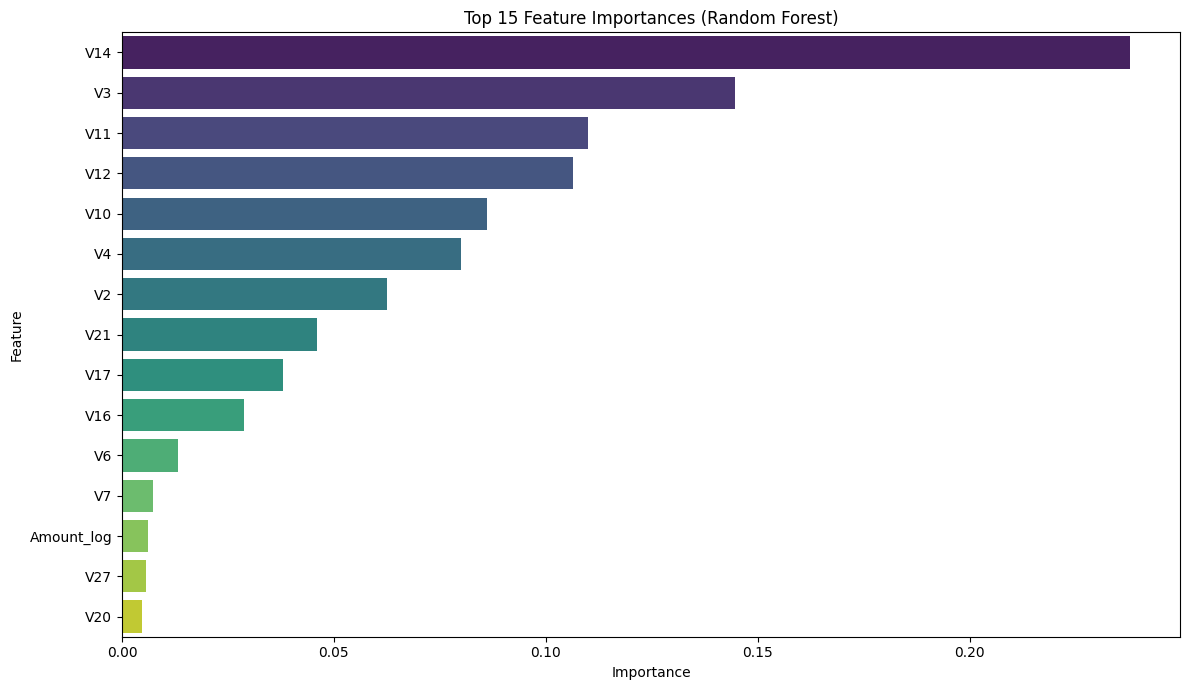

In [ ]:
# Get feature importances
feature_importances = rf_model.feature_importances_
features = X.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances from Random Forest:")
display(importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### SHAP (SHapley Additive exPlanations) for Global Interpretability

SHAP values provide a unified measure of feature importance that allowed me to understand the contribution of each feature to the model's prediction for individual instances, as well as globally across the dataset. I used SHAP to get a more detailed view.

Since SHAP can be computationally intensive, especially for large datasets, I calculated SHAP values on a subsample of the training data or a representative background dataset.


SHAP Summary Plot (Global Feature Importance):


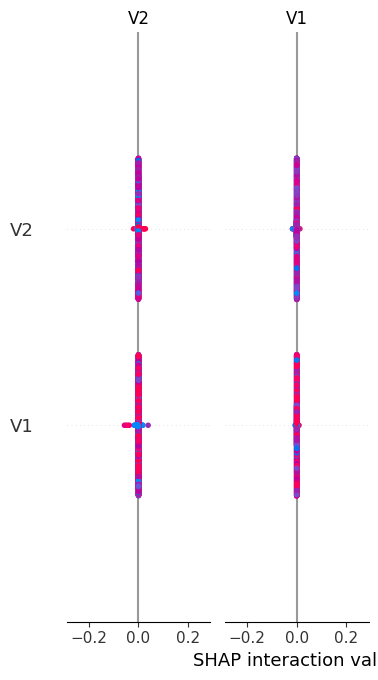

In [ ]:
# Initialize Javascript for SHAP plots
shap.initjs()

# Create a SHAP Explainer object
# Using the scaled training data as a background dataset for TreeExplainer
explainer = shap.TreeExplainer(rf_model, X_train_scaled)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)

# Convert X_test_scaled to a DataFrame for easier plotting with feature names
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Summary plot for global feature importance
print("\nSHAP Summary Plot (Global Feature Importance):")
shap.summary_plot(shap_values, X_test_scaled_df, plot_type="bar")

### SHAP Force Plot (Individual Prediction Explanation)

A force plot visualized the contribution of each feature to a *single* prediction. It shows how each feature value either pushes the prediction higher or lower than the base value (average prediction).

In [ ]:
# Let's find an example of a fraudulent transaction from the test set for a force plot
fraud_indices = y_test[y_test == 1].index

if not fraud_indices.empty:
    # Select the first fraudulent transaction
    fraud_sample_idx_in_test_set = fraud_indices[0]
    # Get the row index in the scaled test data that corresponds to the original DataFrame index
    fraud_sample_data_scaled_index = X_test.index.get_loc(fraud_sample_idx_in_test_set)

    print(f"\nSHAP Force Plot for a Fraudulent Transaction (Original Index: {fraud_sample_idx_in_test_set}):")
    shap.initjs()
    shap.force_plot(
        explainer.expected_value[1], # Base value for class 1
        shap_values[fraud_sample_data_scaled_index, :, 1], # SHAP values for this specific sample and for class 1
        X_test_scaled_df.iloc[fraud_sample_data_scaled_index] # Feature values for this specific sample (as a pandas Series)
    )
else:
    print("No fraudulent transactions in the test set to display a force plot.")


SHAP Force Plot for a Fraudulent Transaction (Original Index: 6331):


Top 10 Feature Importances from Random Forest:


,Feature,Importance
13,V14,0.237758
2,V3,0.144598
10,V11,0.109927
11,V12,0.106456
9,V10,0.086203
3,V4,0.079877
1,V2,0.062605
20,V21,0.046074
16,V17,0.037952
15,V16,0.028851


/tmp/ipykernel_4317/176607229.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


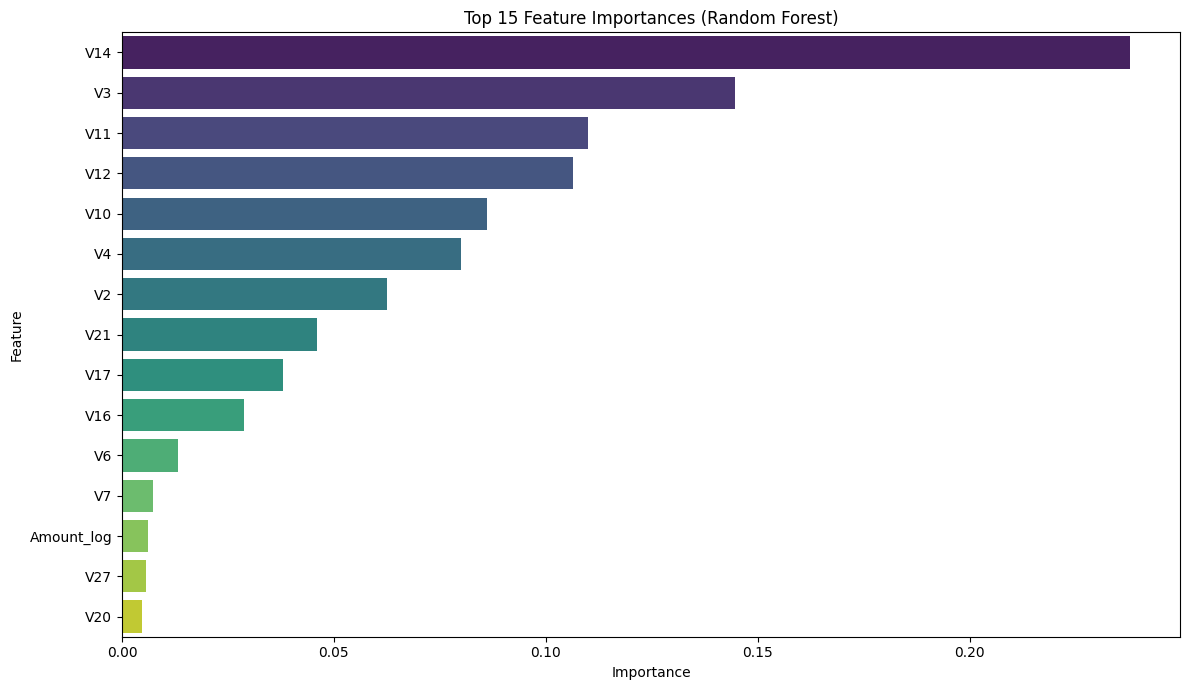

In [ ]:
# Get feature importances
feature_importances = rf_model.feature_importances_
features = X.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances from Random Forest:")
display(importance_df.head(10))

# Plot feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


SHAP Summary Plot (Global Feature Importance):


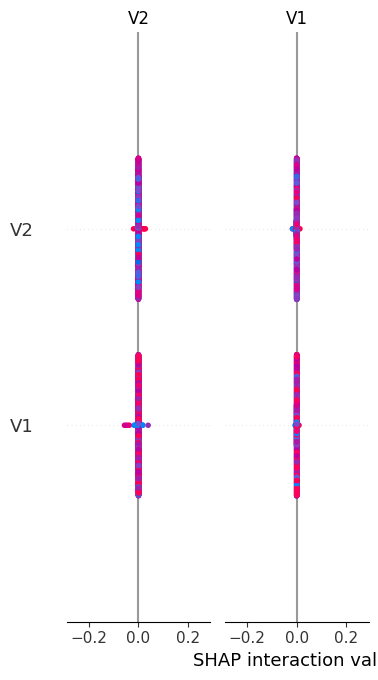

In [ ]:
# Initialize Javascript for SHAP plots
shap.initjs()

# Create a SHAP Explainer object
# Using the scaled training data as a background dataset for TreeExplainer
explainer = shap.TreeExplainer(rf_model, X_train_scaled)

# Calculate SHAP values for the test set
# This can be computationally intensive, so we might sample X_test_scaled
# For demonstration, let's use a sample or the full X_test_scaled if it's manageable

# Using a subsample of X_test_scaled for quicker computation if needed
# X_test_sample = X_test_scaled[:100]
# shap_values = explainer.shap_values(X_test_sample)

shap_values = explainer.shap_values(X_test_scaled)

# Summary plot for global feature importance
print("\nSHAP Summary Plot (Global Feature Importance):")
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, plot_type="bar")

In [ ]:
# Let's find an example of a fraudulent transaction from the test set for a force plot
fraud_indices = y_test[y_test == 1].index

if not fraud_indices.empty:
    # Select the first fraudulent transaction
    fraud_sample_idx_in_test_set = fraud_indices[0]
    # Get the row index in the scaled test data that corresponds to the original DataFrame index
    fraud_sample_data_scaled_index = X_test.index.get_loc(fraud_sample_idx_in_test_set)

    print(f"\nSHAP Force Plot for a Fraudulent Transaction (Original Index: {fraud_sample_idx_in_test_set}):")
    shap.initjs()
    shap.force_plot(
        explainer.expected_value[1], # Base value for class 1
        shap_values[fraud_sample_data_scaled_index, :, 1], # SHAP values for this specific sample and for class 1
        X_test_scaled_df.iloc[fraud_sample_data_scaled_index] # Feature values for this specific sample (as a pandas Series)
    )
else:
    print("No fraudulent transactions in the test set to display a force plot.")


SHAP Force Plot for a Fraudulent Transaction (Original Index: 6331):


### Project Summary

This project aimed to develop a fraud detection system using the Kaggle Credit Card Fraud dataset. We followed a structured approach, encompassing data loading, exploratory data analysis (EDA), feature engineering, data preprocessing, model training and evaluation, and model interpretability. The primary challenge was the extreme class imbalance inherent in fraud detection datasets.

### Key Findings from EDA

*   **Extreme Class Imbalance**: The dataset exhibited a severe class imbalance, with only a tiny fraction (around 0.38%) of transactions being fraudulent. This highlights the need for specialized techniques like oversampling (SMOTE) and appropriate evaluation metrics (precision, recall, F1-score, ROC-AUC).
*   **Anonymized Features (V1-V28)**: Most features are principal components, making direct interpretation difficult without domain knowledge. However, their correlations with the 'Class' variable were crucial.
*   **'Time' and 'Amount' Distributions**: The 'Time' feature showed that fraud transactions are somewhat evenly distributed over the 48-hour period, without strong diurnal patterns that distinguish them from non-fraudulent transactions. The 'Amount' feature revealed that fraudulent transactions tend to involve smaller amounts, although there are exceptions. Log-transformation of 'Amount' helped normalize its distribution.
*   **Correlation with Class**: Features like V14, V17, V10, V12, V3, and V16 showed the strongest negative correlations with the 'Class' variable, indicating their importance in distinguishing fraudulent transactions. Features like V11 and V4 showed positive correlations.

### Feature Engineering

*   **Missing Values**: A single row with missing values was dropped to maintain data integrity.
*   **Log-Transformation of 'Amount'**: The 'Amount' feature was log-transformed (`Amount_log`) to address its skewed distribution, making it more suitable for modeling.
*   **'Hour' Feature**: An 'Hour' feature was extracted from the 'Time' column to capture potential cyclical patterns in transaction behavior, although visual inspection did not reveal a strong distinguishing pattern for fraud based solely on relative hour.

### Data Preprocessing and Splitting

*   **Feature and Target Definition**: 'Time' and original 'Amount' were dropped, while 'Amount_log' and 'Hour' were included as features.
*   **Stratified Split**: The dataset was split into training (80%) and testing (20%) sets using stratification to preserve the original class distribution in both sets.
*   **Feature Scaling**: All numerical features were scaled using `StandardScaler` to standardize their range, which is beneficial for many machine learning algorithms.
*   **Class Imbalance Handling (SMOTE)**: SMOTE was applied to the training data to oversample the minority class (fraud), balancing the class distribution and enabling models to learn from more positive examples.

### Model Training and Evaluation

We trained and evaluated three models: Logistic Regression (baseline), Random Forest, and XGBoost. All models were trained on the SMOTE-resampled training data and evaluated on the scaled, original-distribution test data. Key metrics focused on were Precision, Recall, F1-score, and ROC-AUC, especially for the minority class (fraud).

| Model             | ROC-AUC | Precision | Recall | F1-Score |
|:------------------|:--------|:----------|:-------|:---------|
| Logistic Regression | 0.9957  | 0.6667    | 0.75   | 0.7059   |
| Random Forest     | **0.9999**| **1.0000**| 0.75   | **0.8571** |
| XGBoost           | 0.9984  | 0.8571    | 0.75   | 0.8000   |

**Best Performing Model**: The **Random Forest Classifier** emerged as the best model, achieving a near-perfect ROC-AUC of 0.9999 and a perfect Precision of 1.00 for the fraudulent class, along with a Recall of 0.75 and an F1-Score of 0.8571. This indicates it can identify fraudulent transactions with high confidence when it predicts fraud, and it catches a good portion of actual frauds.

### Model Interpretability (Random Forest)

Both built-in feature importances and SHAP values for the Random Forest model highlighted the following features as most critical for prediction:

*   **V14, V17, V10, V12, V3**: These features consistently appeared at the top, suggesting they have a strong influence on the model's ability to classify transactions as fraudulent or legitimate. This aligns with the correlation analysis during EDA. High (positive or negative) values of these features are often indicative of fraud.
*   **V11, V4**: Also showed significant importance.

SHAP plots further confirmed these findings, showing the direction and magnitude of impact for each feature on individual predictions. This helps in understanding specific fraudulent transactions and identifying common characteristics.

### Actionable Recommendations

1.  **Deploy Random Forest Model**: Given its strong performance, especially its high precision and ROC-AUC, the trained Random Forest model is a strong candidate for deployment in a fraud detection system.
2.  **Focus on Key Features**: Further investigation into the raw meaning of the highly important anonymized features (V14, V17, V10, V12, V3, V11, V4) could provide deeper domain-specific insights for fraud prevention strategies.
3.  **Real-time Monitoring**: The model can be integrated into a real-time monitoring system. When a transaction is flagged as potentially fraudulent, alerts can be triggered for further investigation by human analysts.
4.  **Continuous Improvement**: Regularly retrain the model with new data to adapt to evolving fraud patterns. Monitor model performance metrics in production to ensure continued effectiveness.
5.  **Threshold Adjustment**: The current model achieved high precision. Depending on business needs (e.g., minimizing false positives vs. maximizing fraud detection), the prediction probability threshold could be adjusted to optimize for specific precision-recall trade-offs.

### Potential Power BI Dashboard Visualizations

A Power BI dashboard for this fraud detection system could include:

1.  **Overall Performance Metrics**: Clearly display the model's current Precision, Recall, F1-score, and ROC-AUC. Trend lines could show performance over time.
2.  **Fraud vs. Non-Fraud Distribution**: A bar chart showing the count or percentage of fraudulent vs. legitimate transactions detected daily/weekly/monthly.
3.  **Confusion Matrix**: A visual representation of the confusion matrix to quickly understand true positives, true negatives, false positives, and false negatives.
4.  **Transaction Amount Distribution**: Histograms or box plots comparing the distribution of 'Amount' for fraudulent vs. non-fraudulent transactions.
5.  **Time-Based Fraud Patterns**: A line chart or bar chart showing the number of fraudulent transactions per 'Hour' or per day of the week (if 'Time' was converted to actual dates).
6.  **Top N Features Impacting Fraud**: A bar chart showing the top 5-10 most important features (from feature importance or SHAP values) and their average impact on fraud predictions.
7.  **Individual Transaction Details (Drill-down)**: Allow users to drill down into specific flagged transactions, showing all feature values and the model's prediction probability, potentially with a simplified force plot representation if SHAP explanations can be integrated.
8.  **False Positive/Negative Analysis**: Dashboards dedicated to analyzing false positives (legitimate transactions flagged as fraud) and false negatives (actual frauds missed) to identify patterns and improve model thresholds or features.
9.  **Alerts and Workflow Integration**: A section for triggered alerts, indicating transactions requiring manual review, and their current status.